# Deep Research Agent Demo

This notebook demonstrates the Manus-style deep research agent.

**Architecture highlights:**
- Parent agent delegates research tasks to sub-agents with isolated context
- Sub-agents save full content to a virtual file system; only summaries return to parent
- Parent synthesizes from summaries, reading files selectively when needed

In [1]:
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [2]:
from deep_research_agent.agent import create_deep_research_agent

agent = create_deep_research_agent()

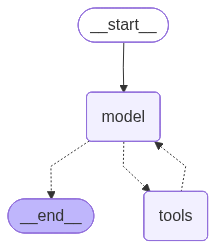

In [3]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [4]:
import os
import sys

# Make examples/ importable when running from this directory
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ]
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "title": "Research Model Context Protocol (MCP)",                                                         │
│       "description": "Gather information and provide an overview of the Model Context Protocol (MCP).",         │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_xsa7qGShQ4Fpx3L1iss6VOJl                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'title': 'Research Model Context Protocol (MCP)', 'description': 'Gather information and │
│ provide an overview of the Model Context Protocol (MCP).', 'status': 'pending'}]                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_todos                                                                                        │
│    Args: {}                                                                                                     │
│    ID: call_3OBl5bpyeqrT1UHLIzSxhTM0                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Current TODO List:                                                                                              │
│ 1. ⏳ Research Model Context Protocol (MCP) (pending)                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "I have gathered comprehensive information about the Model Context Protocol (MCP), including    │
│ its purpose, key features, and applications. The MCP aims to standardize the integration of AI applications     │
│ with external tools, addressing the N×M integration problem. Key features include a client-server model,        │
│ JSON-RPC communication, session management, security measures, and dynamic tool discovery. Applications span    │
│ customer support, personalized learning, and healthcare diagnostics. This overview provides a solid foundation  │
│ for understanding MCP and its significance in AI integration."                                                  │
│ }                                                                                                               │
│    ID: call_Y9t3Fh2OLzcq7TepBWyP8Cos                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: I have gathered comprehensive information about the Model Context Protocol (MCP),          │
│ including its purpose, key features, and applications. The MCP aims to standardize the integration of AI        │
│ applications with external tools, addressing the N×M integration problem. Key features include a client-server  │
│ model, JSON-RPC communication, session management, security measures, and dynamic tool discovery. Applications  │
│ span customer support, personalized learning, and healthcare diagnostics. This overview provides a solid        │
│ foundation for understanding MCP and its significance in AI integration.                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "title": "Research Model Context Protocol (MCP)",                                                         │
│       "description": "Gather information and provide an overview of the Model Context Protocol (MCP).",         │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_A2Wmul9VcwUoBIThf9F0ZRMO                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'title': 'Research Model Context Protocol (MCP)', 'description': 'Gather information and │
│ provide an overview of the Model Context Protocol (MCP).', 'status': 'completed'}]                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ## Overview of Model Context Protocol (MCP)                                                                     │
│                                                                                                                 │
│ ### Purpose                                                                                                     │
│ The Model Context Protocol (MCP) is an open standard designed to facilitate the integration and interaction of  │
│ AI applications with various tools and resources. It addresses the challenges of the “N×M integration problem”  │
│ by standardizing how AI models can access and invoke external tools, simplifying architecture, and reducing the │
│ need for bespoke adapters.                                                                                      │
│                                                                                                                 │
│ ### Key Features                                                                                                │
│ 1. **Client-Server Model:** Operates on a client-server architecture where the server manages resources and     │
│ tools, while clients interact through stateful sessions.                                                        │
│ 2. **JSON-RPC Based:** Utilizes JSON-RPC, a remote procedure call (RPC) protocol encoded in JSON, allowing easy │
│ communication between clients and servers.                                                                      │
│ 3. **Session Management:** Supports host-managed client sessions, enabling the server to maintain context       │
│ across interactions.                                                                                            │
│ 4. **Security Measures:** Incorporates OAuth 2.1 for scoped authorization and addresses security threats        │
│ through techniques like scope checks and session binding.                                                       │
│ 5. **Tool Discovery and Invocation:** Allows AI applications to dynamically discover and invoke                 │
│ tools/resources, enhancing flexibility and usability.                                                           │
│                                                                                                                 │
│ ### Applications                                                                                                │
│ 1. **Customer Support Chatbots:** Enables chatbots to maintain context across multi-turn interactions,          │
│ improving user experience.                                                                                      │
│ 2. **Personalized Learning Platforms:** Helps persist learner progress and preferences, driving adaptive        │
│ recommendations.                                                                                                │
│ 3. **Healthcare Diagnostics Tools:** Coordinates context across patient records and diagnostic workflows,       │
│ minimizing errors in time-sensitive care.                                                                       │
│                                                                                                                 │
│ ### Summary                                                                                                     │
│ The Model Context Protocol is a powerful tool for enhancing the integration and functionality of AI             │
│ applications across various domains, providing a standardized approach to context management and tool           │
│ invocation.                                                                                                     │
│                                                                                                                 │
│ If you have any further questions or need additional in